![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [40]:
# Imports


import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Train/Test Split and Cross Validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

# Display plots nicely
sns.set_style("whitegrid")

In [26]:
df = pd.read_csv("financial_loan_data.csv")

In [27]:
# EDA Code Here - Create New Cells As Needed
# Display the first five rows
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [28]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [29]:
# Summary statistics for numerical columns
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [30]:
# Check missing values
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

### Missing Values

The dataset contains missing values in three variables. EducationLevel and MaritalStatus are categorical variables with missing observations, while SavingsAccountBalance is a numerical variable with missing values. These missing values will be handled during the preprocessing stage using SimpleImputer, where categorical variables will be imputed with the most frequent value and numerical variables with the mean. This approach preserves as much information as possible while allowing the machine learning pipeline to process the data correctly.

In [31]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [32]:
# Display AnnualIncome values
df["AnnualIncome"].head()

0     $39,948.00
1     $39,709.00
2     $40,724.00
3     $69,084.00
4    $103,264.00
Name: AnnualIncome, dtype: object

In [33]:
# Convert AnnualIncome to numeric
df['AnnualIncome'] = (
    df['AnnualIncome']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [34]:
df['AnnualIncome'].dtype

dtype('float64')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  float64
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [36]:
# Check target distribution
df['LoanApproved'].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [37]:
# Percentage distribution
df['LoanApproved'].value_counts(normalize=True) * 100

LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

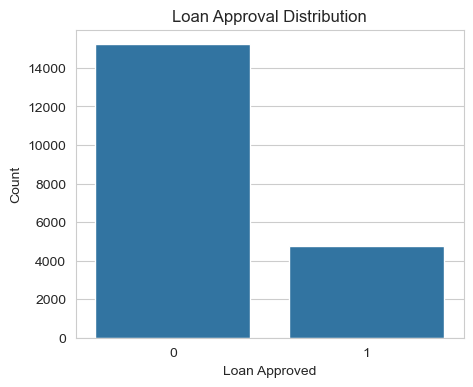

In [38]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='LoanApproved')
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

### Loan Approval Distribution

The target variable is imbalanced. Approximately 76.1% of loan applications were not approved, while 23.9% were approved.

This imbalance means that relying solely on accuracy would be misleading because a model could achieve over 76% accuracy by always predicting "Not Approved." Therefore, additional evaluation metrics such as Recall, Precision, F1-score, and ROC-AUC will be used to better assess model performance.

From a business perspective, the cost of incorrectly rejecting a qualified applicant (false negative) and approving a risky applicant (false positive) should both be considered when selecting the final model.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



## Data Preparation

To prepare the data for machine learning, a preprocessing pipeline will be created to ensure that the same transformations are consistently applied during both training and prediction.

The preprocessing strategy includes:

- Separating numerical and categorical features.
- Handling missing values appropriately:
  - Numerical features will use median imputation because it is more robust to outliers.
  - Categorical features will use the most frequent category.
- Encoding categorical variables using One-Hot Encoding.
- Scaling numerical variables using StandardScaler since algorithms such as Logistic Regression are sensitive to feature scales.
- Combining all preprocessing steps using a ColumnTransformer.
- Integrating preprocessing with the machine learning model using a Pipeline to prevent data leakage and simplify model deployment.

In [41]:
# Data Prep Code Here - Create New Cells As Needed
# Separate features and target

X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

In [42]:
#Define features types
# Numerical features

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical features

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [43]:
# Numerical pipineline
# Numerical preprocessing

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [44]:
# Categorical pipeline
# Categorical preprocessing

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [45]:
# Combine preprocessing

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


## Modeling

The objective is to develop machine learning models capable of predicting whether a loan application will be approved. Two algorithms will be evaluated:

- Logistic Regression as a simple, interpretable baseline.
- Random Forest as a more flexible ensemble model capable of capturing complex relationships.

To obtain reliable estimates of model performance, the dataset will be divided into training and testing sets. Cross-validation will be used during hyperparameter tuning to reduce the risk of overfitting.

Model performance will primarily be evaluated using the **F1-score** because the dataset is moderately imbalanced and both false positives and false negatives are important. ROC-AUC will also be reported to evaluate the model's ability to distinguish between approved and rejected loans across different classification thresholds.

In [46]:
#  Modeling Code Here - Create New Cells as Needed
# Import models and evaluation tools

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [47]:
# Train/test split
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
# Preprocessing Pipelines
# Logistic Regression pipeline

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [49]:
# Random Forest pipeline

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### Hyperparameter Tuning

GridSearchCV is used to systematically evaluate different combinations of hyperparameters. This approach helps identify the model configuration that provides the best balance between model complexity and predictive performance.

Only a small search space is explored to demonstrate the tuning process while keeping computation time reasonable.

In [50]:
# logistic regression grid
# Logistic Regression parameters

lr_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

In [51]:
#random forest grid
# Random Forest parameters

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

In [52]:
# Grid search for Logistic Regression
# Tune Logistic Regression

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'AnnualIncome',
                                                                          'CreditScore',
                                                                          'Experience',
                                                                          'LoanAmount',
                                                                          'LoanDuration',
                                                                          'NumberOfDependents',
                                                                          'MonthlyDebtPayments',
                                                                          'CreditCardUtilizationRate',
                                                                          'NumberOfOpe...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['EmploymentStatus',
                                                                          'EducationLevel',
                                                                          'MaritalStatus',
                                                                          'HomeOwnershipStatus',
                                                                          'BankruptcyHistory',
                                                                          'LoanPurpose'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [53]:
# Grid search for Random Forest
# Tune Random Forest

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'AnnualIncome',
                                                                          'CreditScore',
                                                                          'Experience',
                                                                          'LoanAmount',
                                                                          'LoanDuration',
                                                                          'NumberOfDependents',
                                                                          'MonthlyDebtPayments',
                                                                          'CreditCardUtilizationRate',
                                                                          'NumberOfOpe...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['EmploymentStatus',
                                                                          'EducationLevel',
                                                                          'MaritalStatus',
                                                                          'HomeOwnershipStatus',
                                                                          'BankruptcyHistory',
                                                                          'LoanPurpose'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1')

In [54]:
# Compare models
# Tune Random Forest

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'AnnualIncome',
                                                                          'CreditScore',
                                                                          'Experience',
                                                                          'LoanAmount',
                                                                          'LoanDuration',
                                                                          'NumberOfDependents',
                                                                          'MonthlyDebtPayments',
                                                                          'CreditCardUtilizationRate',
                                                                          'NumberOfOpe...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['EmploymentStatus',
                                                                          'EducationLevel',
                                                                          'MaritalStatus',
                                                                          'HomeOwnershipStatus',
                                                                          'BankruptcyHistory',
                                                                          'LoanPurpose'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1')

In [56]:
print("Random Forest")
print(rf_grid.best_score_)
print(rf_grid.best_params_)

Random Forest
0.9769786830930733
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

# Evaluation and Conclusion

The tuned models are evaluated on the unseen test dataset to assess how well they generalize. Performance is measured using F1-score, precision, recall, ROC-AUC, and the confusion matrix.

The objective is to identify the model that best balances predictive performance with business needs while understanding the factors influencing loan approval decisions.

In [57]:
# Select the best performing model

if rf_grid.best_score_ > lr_grid.best_score_:
    final_model = rf_grid.best_estimator_
    model_name = "Random Forest"
else:
    final_model = lr_grid.best_estimator_
    model_name = "Logistic Regression"

print(model_name)

Logistic Regression


In [58]:
# Predict on the test set

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

In [59]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [60]:
# Display evaluation metrics

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.99975
Precision: 0.9989550679205852
Recall: 1.0
F1-score: 0.9994772608468374
ROC-AUC: 1.0


In [61]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3044
           1       1.00      1.00      1.00       956

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



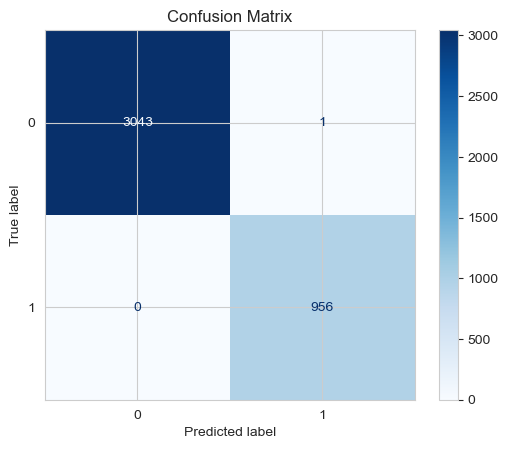

In [62]:
# Plot confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

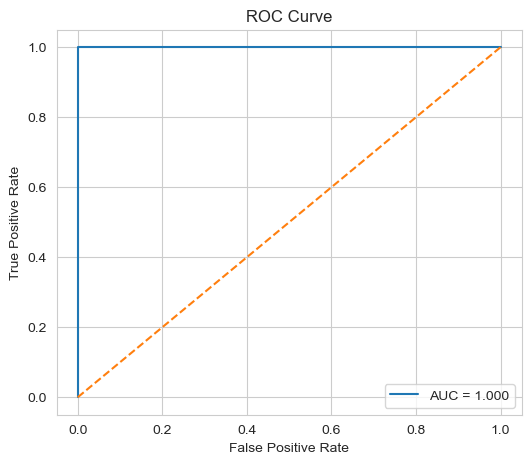

In [63]:
# Plot ROC Curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [66]:
# Extract feature names

feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

In [69]:
# Get feature names
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Get the classifier
model = final_model.named_steps['classifier']

# Feature importance for Random Forest
if hasattr(model, "feature_importances_"):
    importance = model.feature_importances_

# Feature importance for Logistic Regression
else:
    importance = np.abs(model.coef_[0])

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
27,num__RiskScore,8.473588
44,cat__BankruptcyHistory_No,3.274088
24,num__InterestRate,2.555380
11,num__DebtToIncomeRatio,2.481629
28,cat__EmploymentStatus_Employed,2.110889
2,num__CreditScore,1.865070
19,num__MonthlyIncome,1.858840
45,cat__BankruptcyHistory_Yes,1.697246
26,num__TotalDebtToIncomeRatio,1.317590
34,cat__EducationLevel_High School,1.289816


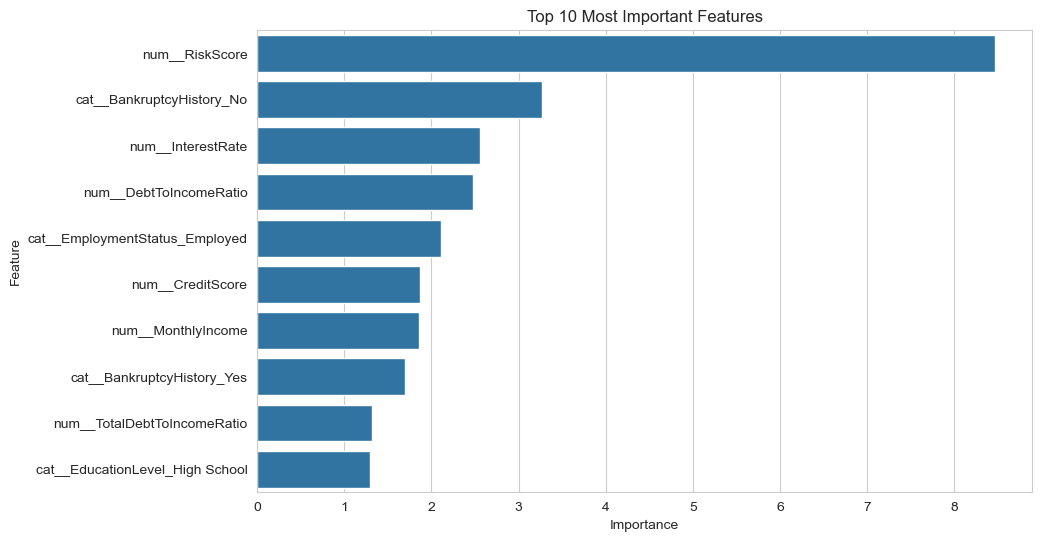

In [70]:
# Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.show()

### Feature Importance Interpretation

The model identified several variables that strongly influence loan approval decisions.

The most influential feature is **RiskScore**, indicating that applicants with lower predicted risk are much more likely to receive loan approval.

Other important variables include:
- Bankruptcy History
- Interest Rate
- Debt-to-Income Ratio
- Employment Status
- Credit Score
- Monthly Income

These variables align with traditional lending practices, where an applicant's financial stability, repayment capacity, and creditworthiness are key factors in approval decisions.

## Business Recommendations

Based on the model results, the following recommendations are proposed:

- Continue prioritizing applicants with strong Risk Scores during the approval process.
- Closely review applicants with previous bankruptcy records before approving loans.
- Consider debt-to-income ratio and interest rate together when assessing repayment ability.
- Verify employment status and income information carefully, as they are important approval indicators.
- Use the model as a decision-support tool to assist loan officers rather than replacing human judgment.

## Business Recommendations

Based on the model results, the following recommendations are proposed:

- Continue prioritizing applicants with strong Risk Scores during the approval process.
- Closely review applicants with previous bankruptcy records before approving loans.
- Consider debt-to-income ratio and interest rate together when assessing repayment ability.
- Verify employment status and income information carefully, as they are important approval indicators.
- Use the model as a decision-support tool to assist loan officers rather than replacing human judgment.

## Future Improvements

Several enhancements could further improve the model:

- Evaluate additional algorithms such as XGBoost, LightGBM, and CatBoost.
- Perform more extensive hyperparameter tuning using RandomizedSearchCV.
- Engineer additional financial features that may improve prediction accuracy.
- Investigate feature selection techniques to reduce model complexity.
- Deploy the model within a monitoring framework to detect performance drift and retrain when necessary.